# Week 3 Laboratory
# Task 2: Image Classification using K-Nearest Neighbours (KNN)

---

## Learning Objectives

After completing this laboratory, you should be able to:

✓ Load image datasets and extract 3D color histogram features using OpenCV.

✓ Split a dataset into **Training (60%)**, **Validation (20%)**, and **Test (20%)** sets.

✓ Perform hyperparameter tuning on a validation set to select the optimal $k$ with early stopping.

✓ Evaluate a KNN classifier using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

✓ Benchmark model inference speed and perform qualitative error analysis on image predictions.

---
## Setup Environment

Install necessary packages to run this notebook.

In [1]:
!pip install opencv-python numpy matplotlib tqdm scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable


---
## 1. Imports & Pre-defined Helper Functions

We first import the required packages and provide four utility functions:
* `preprocess_image`: Reads and resizes an image to $150 \times 150$.
* `extract_color_histogram`: Computes normalized 3D color histograms ($6 \times 6 \times 6 = 216$ bins).
* `load_dataset`: Loads images from `flowers/` across all 5 categories (`daisy`, `dandelion`, `rose`, `sunflower`, `tulip`).
* `show_images`: Displays correctly or incorrectly classified images with titles.

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from timeit import default_timer as timer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

LABELS = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

def preprocess_image(path_to_image, img_size=150):
    """Read and resize an input image."""
    img = cv2.imread(path_to_image, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (img_size, img_size))
    return np.array(img)

def extract_color_histogram(dataset, hist_size=6):
    """Extract color histogram features from a dataset of images."""
    col_hist = []
    for img in dataset:
        hist = cv2.calcHist([img], [0, 1, 2], None, (hist_size, hist_size, hist_size), [0, 256, 0, 256, 0, 256])
        col_hist.append(cv2.normalize(hist, None, 0, 1, cv2.NORM_MINMAX).flatten())
    return np.array(col_hist)

def load_dataset(base_path='flowers'):
    """Load dataset images and labels."""
    X, Y = [], []
    for i in range(len(LABELS)):
        current_size = len(X)
        dir_path = os.path.join(base_path, LABELS[i])
        if os.path.exists(dir_path):
            for img in tqdm(os.listdir(dir_path), desc=f"Loading {LABELS[i]}"):
                if not img.startswith('.'):
                    X.append(preprocess_image(os.path.join(dir_path, img)))
                    Y.append(LABELS[i])
            print(f'Loaded {len(X) - current_size} {LABELS[i]} images')
    return X, Y

def show_images(ground_truth, predictions, img_test, correct=True, num_images=5):
    """Show correctly or incorrectly classified images."""
    count = 0
    plt.figure(figsize=(15, 3))
    for i in range(len(ground_truth)):
        if (ground_truth[i] == predictions[i]) == correct:
            count += 1
            plt.subplot(1, num_images, count)
            plt.imshow(cv2.cvtColor(img_test[i], cv2.COLOR_BGR2RGB))
            plt.title(f"GT: {ground_truth[i]}\nPred: {predictions[i]}", fontsize=9)
            plt.axis('off')
            if count == num_images:
                break
    plt.tight_layout()
    plt.show()

print("Environment set up successfully!")

Environment set up successfully!


---
## STEP 1. Load Dataset

Load the flower image dataset into memory using `load_dataset()`.

In [3]:
# STEP 1. Load dataset
X, Y = load_dataset('flowers')
print(f"Total samples loaded: {len(X)}")

Loading daisy:   0%|          | 0/764 [00:00<?, ?it/s]

Loading daisy:  12%|█▏        | 88/764 [00:00<00:00, 862.30it/s]

Loading daisy:  26%|██▌       | 195/764 [00:00<00:00, 981.05it/s]

Loading daisy:  38%|███▊      | 294/764 [00:00<00:00, 985.05it/s]

Loading daisy:  54%|█████▍    | 412/764 [00:00<00:00, 1058.35it/s]

...

Loading tulip:  78%|███████▊  | 764/984 [00:00<00:00, 906.67it/s]

Loading tulip:  88%|████████▊ | 866/984 [00:00<00:00, 941.00it/s]

Loading tulip:  98%|█████████▊| 961/984 [00:01<00:00, 936.76it/s]

Loading tulip: 100%|██████████| 984/984 [00:01<00:00, 911.44it/s]

Loaded 984 tulip images
Total samples loaded: 4317


---
## STEP 2. Split Dataset (Train, Validation, Test)

We split the dataset into three subsets:
* **Train Set (60%)**: Fits the KNN model.
* **Validation Set (20%)**: Tunes the hyperparameter $k$.
* **Test Set (20%)**: Held-out set for final model evaluation.

### Task:
Use `train_test_split` twice:
1. Reserve 20% of data for validation (`img_val`, `y_val`).
2. Reserve 20% of original data (25% of remaining) for testing (`img_test`, `y_test`).

In [4]:
# STEP 2. Split dataset into train, validation, and test sets
# 2.1 Reserve 20% of data as validation set
img_train, img_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=1)

# 2.2 Reserve 20% of original data as test set (0.8 * 0.25 = 0.2)
img_train, img_test, y_train, y_test = train_test_split(img_train, y_train, test_size=0.25, random_state=1)

print(f"Training samples  : {len(img_train)} ({len(img_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(img_val)} ({len(img_val)/len(X)*100:.1f}%)")
print(f"Test samples      : {len(img_test)} ({len(img_test)/len(X)*100:.1f}%)")

Training samples  : 2589 (60.0%)
Validation samples: 864 (20.0%)
Test samples      : 864 (20.0%)


---
## STEP 3. Feature Extraction

Extract 3D color histogram feature vectors ($216$ dimensions per image) from the training, validation, and test image sets.

### Task:
Apply `extract_color_histogram` to `img_train`, `img_val`, and `img_test` to produce `x_train`, `x_val`, and `x_test`.

In [5]:
# STEP 3. Extract colour histogram features from the datasets
x_train = extract_color_histogram(img_train)
x_val = extract_color_histogram(img_val)
x_test = extract_color_histogram(img_test)

print(f"x_train shape: {x_train.shape}")
print(f"x_val shape  : {x_val.shape}")
print(f"x_test shape : {x_test.shape}")

x_train shape: (2589, 216)
x_val shape  : (864, 216)
x_test shape : (864, 216)


---
## STEP 4. Determine Optimal Value of $k$

Search for the optimal $k$ by training `KNeighborsClassifier(n_neighbors=k)` on `x_train` and evaluating accuracy on `x_val`.

### Early Stopping
To optimize search speed, stop early if validation accuracy fails to improve for `EARLY_STOP = 100` consecutive steps.

### Task:
Complete the hyperparameter tuning loop below.

In [6]:
# STEP 4. Determine the optimal values of k
validation_performance = []
best_index = 0
optimal_k = 1
EARLY_STOP = 100
K_VALUES = list(range(1, len(x_train) + 1))

for k in tqdm(K_VALUES, desc="Tuning k"):
    # 4.1 Initialize k-NN classifier and fit on training set
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(x_train, y_train)

    # 4.2 Evaluate on validation set
    val_predictions = knn_model.predict(x_val)
    val_accuracy = accuracy_score(y_val, val_predictions)

    # 4.3 Store performance
    validation_performance.append(val_accuracy)

    # 4.4 Check if performance improves
    if val_accuracy > validation_performance[best_index]:
        best_index = len(validation_performance) - 1
        optimal_k = k

    # 4.5 Early stopping
    if len(validation_performance) > EARLY_STOP and len(validation_performance) - best_index > EARLY_STOP:
        print(f"\nEarly stopping triggered at k = {k}")
        break

print(f"The optimal value of k is: {optimal_k} (Val Acc: {validation_performance[best_index]*100:.2f}%)")

Tuning k:   0%|          | 0/2589 [00:00<?, ?it/s]

Tuning k:   0%|          | 6/2589 [00:00<00:46, 56.10it/s]

Tuning k:   1%|          | 15/2589 [00:00<00:35, 71.60it/s]

Tuning k:   1%|          | 24/2589 [00:00<00:32, 78.32it/s]

Tuning k:   1%|          | 32/2589 [00:00<00:47, 54.16it/s]

...

Tuning k:   4%|▎         | 97/2589 [00:01<00:49, 50.54it/s]

Tuning k:   4%|▍         | 103/2589 [00:01<00:48, 51.66it/s]

Tuning k:   4%|▍         | 109/2589 [00:01<00:50, 49.07it/s]

Tuning k:   4%|▍         | 113/2589 [00:02<00:45, 54.09it/s]


Early stopping triggered at k = 114
The optimal value of k is: 14 (Val Acc: 44.56%)


Let's plot Validation Accuracy vs. $k$ to visualize the search.

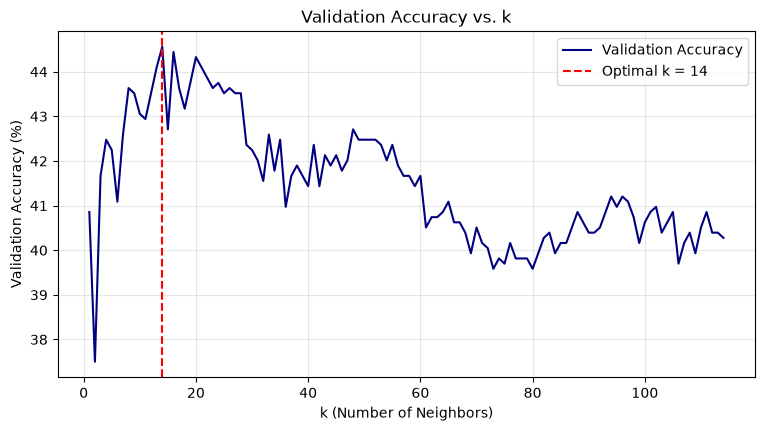

In [7]:
plt.figure(figsize=(9, 4.5))
plt.plot(K_VALUES[:len(validation_performance)], [acc * 100 for acc in validation_performance], color='navy', label='Validation Accuracy')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.title('Validation Accuracy vs. k', fontsize=12)
plt.xlabel('k (Number of Neighbors)', fontsize=10)
plt.ylabel('Validation Accuracy (%)', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## STEP 5. Train KNN Classifier with Optimal $k$

Train the final `KNeighborsClassifier` using `n_neighbors=optimal_k` on `x_train` and `y_train`.

In [8]:
# STEP 5. Train a k-NN classifier with the optimal k
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(x_train, y_train)
print("Model trained successfully!")

Model trained successfully!


---
## STEP 6. Benchmark Inference Speed on Test Set

Measure the average inference time per test image over 10 runs using `timer()`.

In [9]:
# STEP 6. Evaluate the k-NN on the test dataset
inference_times = []
for _ in range(10):
    start_time = timer()
    y_pred = knn_model.predict(x_test)
    end_time = timer()
    inference_times.append((end_time - start_time) / len(x_test))

average_inference_time = np.mean(inference_times)
print(f"Average inference time: {average_inference_time:.6f} seconds/image ({average_inference_time * 1000:.3f} ms/image)")

Average inference time: 0.000012 seconds/image (0.012 ms/image)


---
## STEP 7. Report Classification Metrics

Calculate Accuracy, Precision, Recall, and F1-score on the test set predictions `y_pred`.

In [10]:
# STEP 7. Report the classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.4606
Precision: 0.4917
Recall   : 0.4565
F1-score : 0.4626


---
## STEP 8. Plot Confusion Matrix

Display the confusion matrix for test predictions.

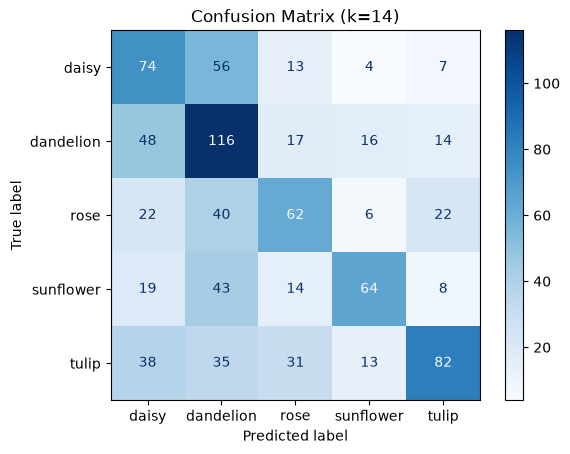

In [11]:
# STEP 8. Plot the confusion matrix
matrix_values = confusion_matrix(y_test, y_pred, labels=LABELS)
confusion_matrix_display = ConfusionMatrixDisplay(matrix_values, display_labels=LABELS)
confusion_matrix_display.plot(cmap='Blues')
plt.title(f'Confusion Matrix (k={optimal_k})', fontsize=12)
plt.show()

---
## STEP 9. Show Classified Images

Display top 5 correctly classified images and top 5 incorrectly classified images using `show_images`.

Top 5 correctly-classified images:


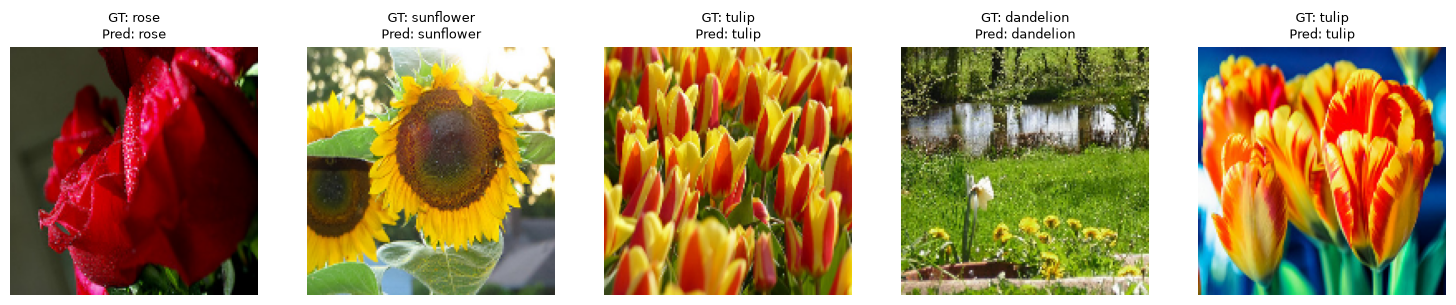

Top 5 incorrectly-classified images:


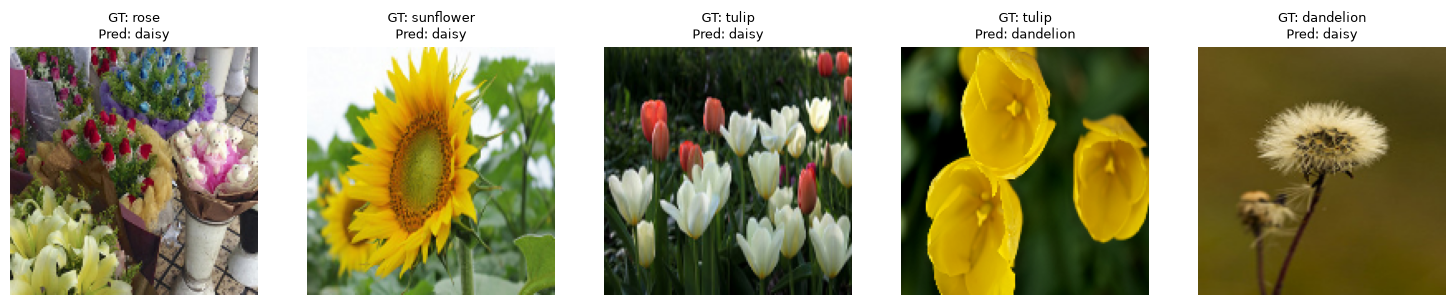

In [12]:
# STEP 9. Show 5 correctly/incorrectly classified images
print("Top 5 correctly-classified images:")
show_images(ground_truth=y_test, predictions=y_pred, img_test=img_test, correct=True, num_images=5)

print("Top 5 incorrectly-classified images:")
show_images(ground_truth=y_test, predictions=y_pred, img_test=img_test, correct=False, num_images=5)

---
## Reflection Questions

1. **Q1:** Why do we need a separate **Validation Set** to find $k$, instead of picking $k$ based on performance on the **Test Set**?
   * **Answer:** Tuning $k$ on the test set causes data leakage, making test performance overly optimistic. The test set must be used only once for unbiased evaluation.

2. **Q2:** Why are 3D color histograms invariant to rotation and scale, but sensitive to lighting variations?
   * **Answer:** Histograms count global color frequencies without spatial position information, making them invariant to rotation/scaling. However, lighting changes shift pixel color values into different histogram bins.

3. **Q3:** Why is KNN inference speed slow on large image datasets?
   * **Answer:** KNN is a non-parametric model that computes distances between query samples and all training samples at prediction time ($O(N_{train} \cdot D)$ per query).